# **Project Name**    - DeepCSAT – Ecommerce Customer Satisfaction Score Prediction



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Author**  - Abhinav Jotiram Shinde

# **Project Summary -**

This project aims to predict Customer Satisfaction (CSAT) scores for an e-commerce platform using deep learning techniques. Customer satisfaction is an important factor for online businesses because it directly affects customer retention, brand reputation, and overall business growth. The objective of this project is to build a predictive model that can estimate CSAT scores based on customer interaction and transaction data, enabling businesses to identify service issues and improve customer experience.

The dataset used in this project contains customer support interaction records from the e-commerce platform “Shopzilla”. It includes features such as channel name, issue category, order details, timestamps of issue reporting and response, customer city, product category, item price, handling time, and agent details. The target variable for prediction is the **CSAT Score**, representing the level of customer satisfaction.

The project began with **data wrangling and preprocessing**, where missing values were handled, irrelevant columns were removed, and date-time fields were properly formatted. Categorical variables were converted into numerical form using **one-hot encoding** so that they could be used in machine learning models. Exploratory Data Analysis (EDA) was then performed using visualizations such as count plots, bar charts, and correlation heatmaps to understand patterns in the data. The dataset was found to be **imbalanced**, so class weights were applied during model training.

Three **Artificial Neural Network (ANN)** models were developed and evaluated using Accuracy, Precision, Recall, and F1 Score. Since the dataset is imbalanced, the **F1 Score** was considered the most reliable metric. Among the models, **Model 2 achieved the best performance**, with an accuracy of approximately **66.96%** and the highest F1 score.

The best model was saved using **joblib** and reloaded to verify predictions on unseen data, confirming that it is ready for deployment. This project demonstrates how deep learning can help e-commerce companies predict customer satisfaction and improve service quality through data-driven insights.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Customer satisfaction is a key factor in the success of e-commerce platforms, as it directly affects customer retention, brand reputation, and overall business growth. Companies typically measure satisfaction through Customer Satisfaction (CSAT) surveys after customer interactions. However, relying solely on survey responses can be inefficient and may not provide immediate insights into customer experience. Therefore, there is a need for a predictive system that can estimate customer satisfaction levels using data generated during customer support interactions.

The objective of this project is to develop a machine learning and deep learning model capable of predicting the CSAT score based on historical customer interaction data. The dataset includes features such as support channel, issue category, order details, response times, product information, and agent-related attributes. By analyzing these factors and building predictive models, the system aims to forecast customer satisfaction levels, enabling businesses to identify potential service issues, improve support processes, and enhance the overall customer experience through data-driven decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

import re
from nltk.corpus import stopwords
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("eCommerce_Customer_support_data.csv")

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

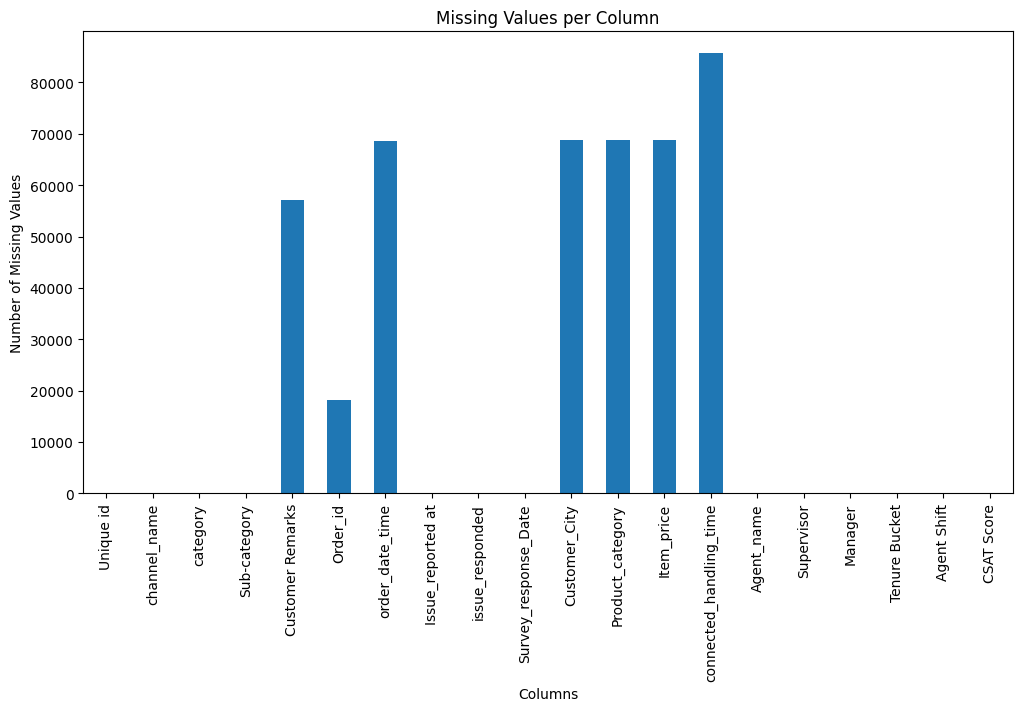

In [8]:
# Visualizing the missing values
missing_values = df.isnull().sum()

missing_values.plot(kind='bar', figsize=(12,6))

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.show()

### What did you know about your dataset?

After performing basic data analysis, it was observed that the dataset contains **85,907 rows and 20 columns**, representing customer support interactions on an e-commerce platform. The dataset includes a mixture of categorical, numerical, text, and datetime features such as channel name, issue category, product category, item price, customer remarks, and timestamps related to issue reporting and response. An analysis of missing values revealed that several columns contained null entries. For example, **Customer Remarks had 57,165 missing values, Order_id had 18,232 missing values, order_date_time had 68,693 missing values, Customer_City had 68,828 missing values, Product_category had 68,711 missing values, Item_price had 68,701 missing values, and connected_handling_time had 85,665 missing values**, while other columns such as channel_name, category, sub-category, agent details, and the target variable **CSAT Score** did not contain missing values. The dataset also showed that the CSAT score distribution was imbalanced, with most customers giving higher satisfaction scores compared to lower scores, which indicated the need for appropriate handling of class imbalance during model training.


## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [10]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
df.nunique

<bound method DataFrame.nunique of                                   Unique id channel_name         category  \
0      7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1      b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2      200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3      eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4      ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   
...                                     ...          ...              ...   
85902  505ea5e7-c475-4fac-ac36-1d19a4cb610f      Inbound   Refund Related   
85903  44b38d3f-1523-4182-aba2-72917586647c      Inbound    Order Related   
85904  723bce2c-496c-4aa8-a64b-ca17004528f0      Inbound    Order Related   
85905  707528ee-6873-4192-bfa9-a491f1c08ab5      Inbound         Feedback   
85906  07c7a878-0d5a-42e0-97ef-de59abec0238      Inbound          Returns   

                       Sub-category     

## ***3. Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df = df.drop(columns=[
    "connected_handling_time",
    "order_date_time",
    "Order_id"
])

In [13]:
df["Customer Remarks"] = df["Customer Remarks"].fillna("No Remark")

df["Customer_City"] = df["Customer_City"].fillna("Unknown")

df["Product_category"] = df["Product_category"].fillna("Unknown")

In [14]:
df["Item_price"] = df["Item_price"].fillna(df["Item_price"].median())

## ***4. Feature Engineering***

### 1. Handling Outliers

In [15]:
df["Issue_reported at"] = pd.to_datetime(df["Issue_reported at"], dayfirst=True)
df["issue_responded"] = pd.to_datetime(df["issue_responded"], dayfirst=True)
df["Survey_response_Date"] = pd.to_datetime(df["Survey_response_Date"], dayfirst=True)

C:\Users\Abhinav J. Shinde\AppData\Local\Temp\ipykernel_21952\2823170563.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Survey_response_Date"] = pd.to_datetime(df["Survey_response_Date"], dayfirst=True)


In [16]:
df["response_time"] = (
    df["issue_responded"] - df["Issue_reported at"]
).dt.total_seconds() / 3600

In [17]:
df["issue_hour"] = df["Issue_reported at"].dt.hour
df["issue_day"] = df["Issue_reported at"].dt.dayofweek

In [18]:
df["remark_length"] = df["Customer Remarks"].apply(len)

In [19]:
df.isnull().sum()

Unique id               0
channel_name            0
category                0
Sub-category            0
Customer Remarks        0
Issue_reported at       0
issue_responded         0
Survey_response_Date    0
Customer_City           0
Product_category        0
Item_price              0
Agent_name              0
Supervisor              0
Manager                 0
Tenure Bucket           0
Agent Shift             0
CSAT Score              0
response_time           0
issue_hour              0
issue_day               0
remark_length           0
dtype: int64

In [20]:
df["CSAT Score"].value_counts()

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64

In [21]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,...,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time,issue_hour,issue_day,remark_length
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remark,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Unknown,Unknown,...,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.566667,11,1,9
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remark,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Unknown,Unknown,...,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.033333,12,1,9
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remark,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Unknown,Unknown,...,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0.366667,20,1,9
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remark,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Unknown,Unknown,...,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0.333333,20,1,9
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remark,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Unknown,Unknown,...,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0.033333,10,1,9


### What all manipulations have you done and insights you found?

Several data manipulation and preprocessing steps were performed to prepare the dataset for modeling. Missing values were handled by filling them with suitable placeholders such as “Unknown” or “No Remark”, while columns with extremely high missing values were removed. Irrelevant identifier columns like unique IDs and order IDs were dropped since they do not contribute to prediction. Date-time columns were converted into proper formats and used to create useful features such as response time, issue hour, and issue day.

## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

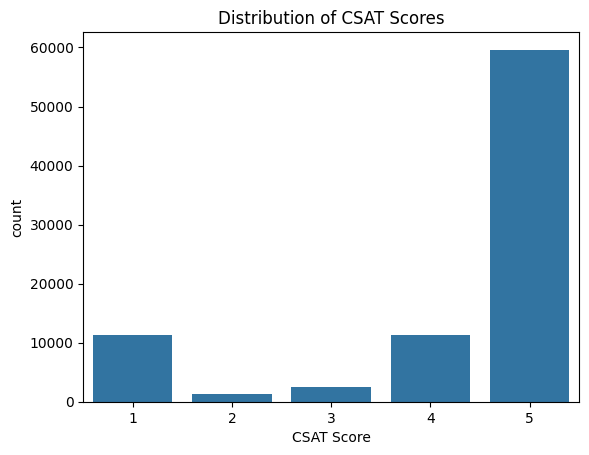

In [22]:
# Chart - 1 visualization code
sns.countplot(x="CSAT Score", data=df)
plt.title("Distribution of CSAT Scores")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot/bar chart was chosen because it is the most suitable visualization to display the frequency distribution of categorical or discrete variables such as CSAT scores. Since CSAT scores range from 1 to 5, the count plot clearly shows how many customers gave each satisfaction rating. This helps quickly understand the overall satisfaction pattern and identify whether the dataset is balanced or skewed toward certain ratings.

##### 2. What is/are the insight(s) found from the chart?

From the chart, it is clear that CSAT score 5 has the highest number of responses, indicating that most customers reported very high satisfaction with the service. Scores 1 and 4 also have noticeable counts, while scores 2 and 3 appear much less frequently, showing that moderate satisfaction levels are relatively rare. This indicates that the dataset is imbalanced, with the majority of customers giving the highest satisfaction rating. The chart suggests that while overall customer satisfaction is generally high, there are still some customers who report lower satisfaction scores, which may be related to service delays, issue handling quality, or product-related problems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact because they show that a large portion of customers are satisfied, indicating that the company’s support system is generally effective. However, the presence of low CSAT scores (1, 2, and 3) highlights areas where service quality may need improvement. The imbalance in the dataset may also lead to biased machine learning models that predict higher satisfaction more frequently, which could reduce the model’s ability to detect dissatisfied customers. If these low satisfaction cases are not addressed, they could lead to customer churn, negative reviews, and potential loss of business growth, making it important for the company to analyze and resolve the causes behind lower CSAT ratings.

#### Chart - 2

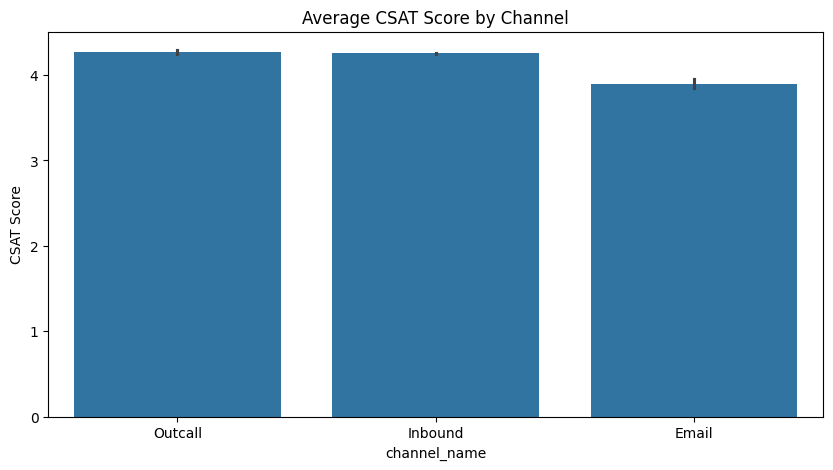

In [23]:
# Chart - 2 visualization code
plt.figure(figsize=(10,5))
sns.barplot(x="channel_name", y="CSAT Score", data=df)
plt.title("Average CSAT Score by Channel")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is effective for comparing the average CSAT score across different customer service channels. Since the objective is to understand how customer satisfaction varies between channels such as Outcall, Inbound, and Email, the bar chart clearly highlights differences in their average scores and makes it easy to compare service performance across these channels.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Outcall and Inbound channels have very similar and slightly higher average CSAT scores, indicating that customers interacting through these channels tend to be more satisfied. On the other hand, the Email channel has a noticeably lower average CSAT score, suggesting that customers who receive support through email may experience slightly lower satisfaction. This could be due to slower response times, delayed issue resolution, or less interactive communication compared to phone-based channels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact because they highlight which support channels perform better in terms of customer satisfaction. The company can analyze the practices used in Inbound and Outcall channels and apply similar improvements to the Email support channel to enhance customer experience. However, the relatively lower CSAT score for email support could indicate potential negative impact on customer satisfaction if not addressed, as slower or less effective communication may lead to frustrated customers and reduced loyalty. Improving response efficiency and communication quality in the email channel could help prevent this issue and improve overall service performance.

#### Chart - 3

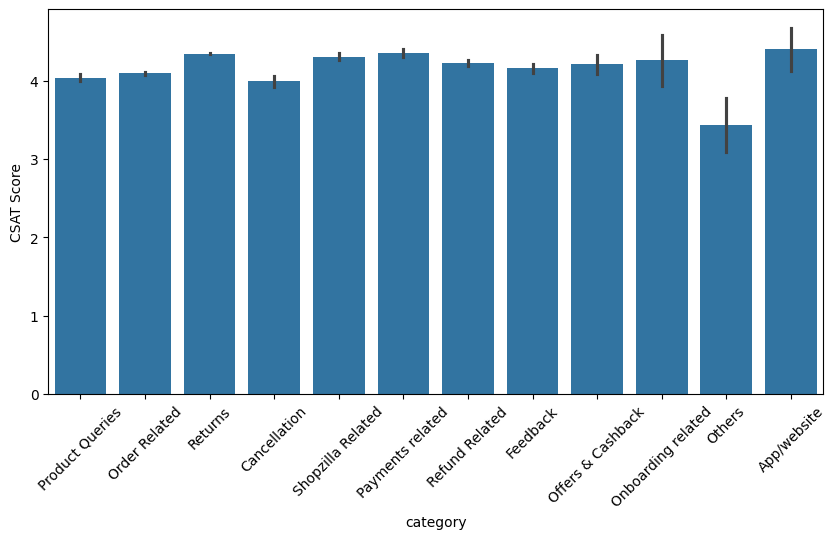

In [24]:
# Chart - 3 visualization code
plt.figure(figsize=(10,5))
sns.barplot(x="category", y="CSAT Score", data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it effectively compares the average CSAT score across different issue categories. Since each category represents a different type of customer concern (such as product queries, refunds, cancellations, and app/website issues), the bar chart clearly shows how customer satisfaction varies between these categories, making it easier to identify which types of issues result in higher or lower satisfaction levels.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most categories have average CSAT scores above 4, indicating that customers are generally satisfied with the support they receive across most issue types. Categories such as Returns, Payments related, and App/Website issues appear to have relatively higher satisfaction levels. However, the “Others” category has a noticeably lower average CSAT score compared to the rest, suggesting that issues grouped under this category may not be handled as effectively or may represent more complex problems that lead to lower customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact by helping the company identify which issue categories are handled well and which require improvement. For example, the lower satisfaction in the “Others” category indicates that customers facing these issues may experience unresolved problems or unclear support processes. If these issues are not addressed, it could lead to customer dissatisfaction, negative reviews, and reduced customer loyalty, potentially affecting business growth. By analyzing and improving support processes for categories with lower CSAT scores, the company can enhance customer experience and maintain high satisfaction levels across all service areas.

#### Chart - 4

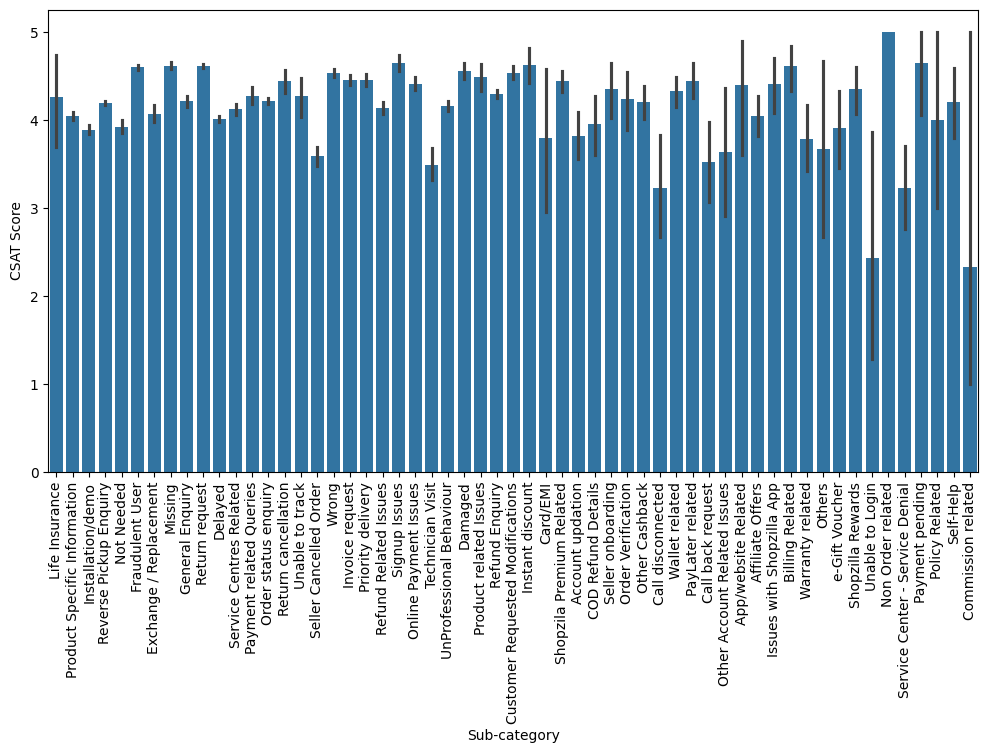

In [25]:
# Chart - 4 visualization code
plt.figure(figsize=(12,6))
sns.barplot(x="Sub-category", y="CSAT Score", data=df)
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it effectively compares the average CSAT score across different sub-categories of customer issues. Since each sub-category represents a specific type of problem or customer interaction, this visualization helps clearly observe how customer satisfaction varies across different service areas and highlights which specific issues lead to higher or lower satisfaction levels.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most sub-categories have average CSAT scores above 4, indicating that overall customer satisfaction across most issue types is relatively high. However, a few sub-categories display lower average CSAT scores and larger variability, suggesting that customers facing those issues may experience more dissatisfaction or inconsistent service. This indicates that while most services are performing well, certain specific issue types may require more attention from the support team.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact by helping the company identify which specific support issues are handled effectively and which areas need improvement. Sub-categories with consistently high CSAT scores indicate strong service performance, while those with lower scores highlight potential problem areas where customers may be experiencing delays, unresolved issues, or inefficient support. If these lower-performing sub-categories are not addressed, they could lead to customer dissatisfaction, negative feedback, and reduced customer loyalty, which may negatively affect business growth. By improving processes and training support teams in these areas, the company can enhance customer satisfaction and strengthen overall service quality.

#### Chart - 5

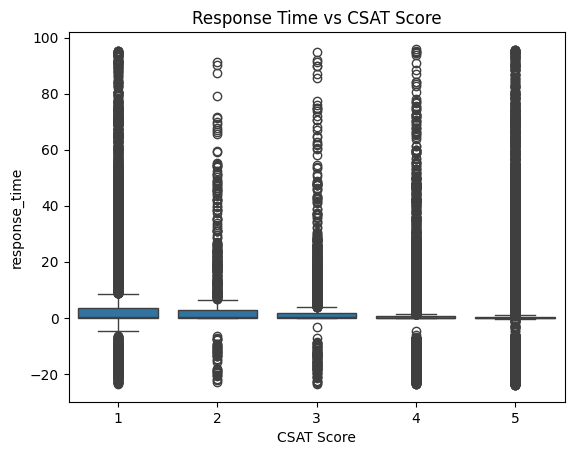

In [26]:
# Chart - 5 visualization code
sns.boxplot(x="CSAT Score", y="response_time", data=df)
plt.title("Response Time vs CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen because it is useful for showing the distribution, spread, and presence of outliers in numerical data across different categories. In this case, it helps visualize how response time varies for each CSAT score level and allows us to understand whether longer or shorter response times are associated with higher or lower customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

From the chart, it can be observed that the median response time for most CSAT score levels is relatively low, suggesting that many customer issues are resolved quickly. However, there are several outliers with very high response times, indicating that some cases take significantly longer to resolve. These longer response times may contribute to lower satisfaction in certain situations. The chart also shows variability in response times across CSAT levels, suggesting that response efficiency may influence customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact by highlighting the importance of faster response and resolution times in improving customer satisfaction. If companies focus on reducing response times and managing cases that take unusually long to resolve, they can improve overall CSAT scores and customer experience. However, the presence of extreme response time outliers indicates potential inefficiencies in the support process. If these delays are not addressed, they may lead to customer dissatisfaction, negative feedback, and reduced customer loyalty, which could negatively affect business growth.

#### Chart - 6

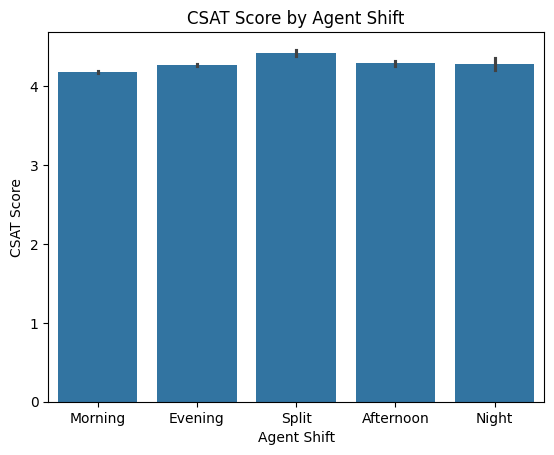

In [27]:
# Chart - 6 visualization code
sns.barplot(x="Agent Shift", y="CSAT Score", data=df)
plt.title("CSAT Score by Agent Shift")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is effective for comparing the average CSAT scores across different agent shifts. Since agent shift is a categorical variable, the bar chart clearly shows differences in customer satisfaction levels between shifts and makes it easy to identify which shift performs better or worse.

##### 2. What is/are the insight(s) found from the chart?

From the chart, it can be observed that CSAT scores are relatively similar across all shifts, indicating consistent service quality throughout the day. However, the Split shift appears to have slightly higher CSAT scores, while the Morning shift shows comparatively lower scores. This suggests that certain shifts may handle customer interactions more effectively than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact by helping organizations analyze agent performance across shifts and identify which shifts deliver the best customer experience. Management can study the practices of higher-performing shifts and replicate them across other shifts to improve overall customer satisfaction. However, if lower-performing shifts are not addressed, they may lead to slightly reduced customer satisfaction and inconsistent service quality, which could negatively affect customer experience over time.

#### Chart - 7

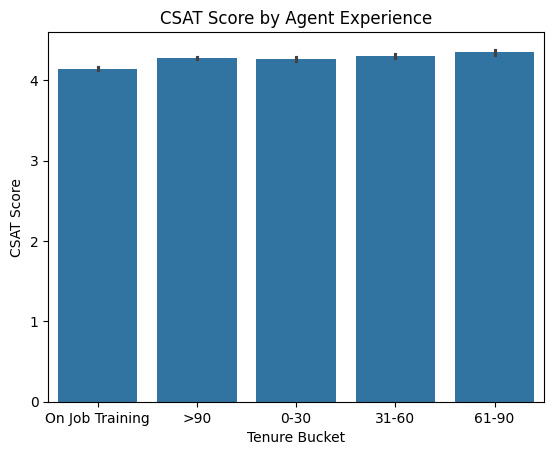

In [28]:
# Chart - 7 visualization code
sns.barplot(x="Tenure Bucket", y="CSAT Score", data=df)
plt.title("CSAT Score by Agent Experience")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it clearly compares the average CSAT scores across different tenure buckets (levels of agent experience). Since tenure bucket is a categorical variable and CSAT score is numerical, the bar chart effectively highlights how customer satisfaction varies with agent experience.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that CSAT scores slightly increase as agent experience increases. Agents with longer tenure (such as 61–90 days and >90 days) tend to achieve slightly higher CSAT scores compared to agents who are On Job Training or in early tenure buckets. This suggests that more experienced agents may handle customer issues more efficiently and provide better service.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact by emphasizing the importance of agent training and experience in improving customer satisfaction. Organizations can invest in better onboarding, mentoring, and training programs to help new agents reach the performance level of experienced agents more quickly. However, the relatively lower CSAT scores for agents in the On Job Training stage indicate that insufficient training or lack of experience could negatively affect customer satisfaction if not properly managed.

#### Chart - 8

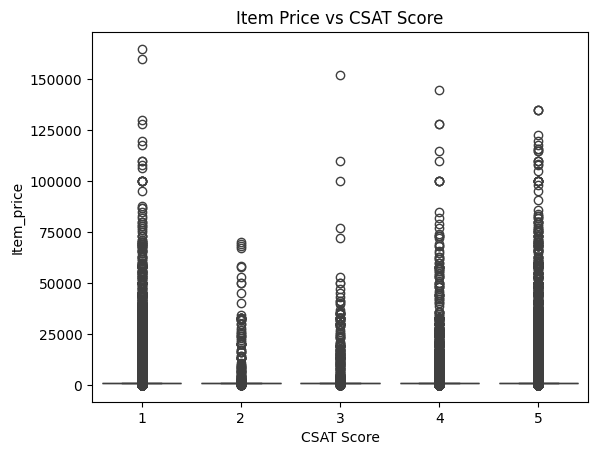

In [29]:
# Chart - 8 visualization code
sns.boxplot(x="CSAT Score", y="Item_price", data=df)
plt.title("Item Price vs CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen because it is effective for examining the relationship between two numerical variables, in this case Item Price and CSAT Score. It helps visualize how customer satisfaction varies across different price ranges and whether higher-priced items tend to receive different satisfaction scores compared to lower-priced items.

##### 2. What is/are the insight(s) found from the chart?

From the chart, it appears that CSAT scores are distributed across all item price ranges, meaning both low-priced and high-priced items can receive high or low satisfaction scores. However, a large concentration of transactions occurs at lower price levels, while higher-priced items appear as scattered outliers. This suggests that item price alone may not strongly determine customer satisfaction, and other factors such as service quality, issue resolution, or response time may play a larger role.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses understand that customer satisfaction is not solely dependent on product price, but rather on the overall customer experience. Companies should focus on improving support services, response efficiency, and issue resolution for all customers regardless of purchase value. However, if high-priced items receive poor service or unresolved issues, it could lead to greater dissatisfaction among high-value customers, which may negatively impact brand reputation and long-term customer loyalty.

#### Chart - 9

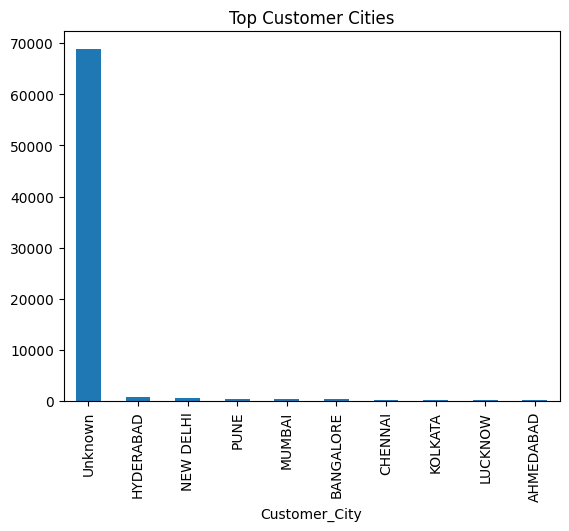

In [30]:
# Chart - 9 visualization code
df["Customer_City"].value_counts().head(10).plot(kind="bar")
plt.title("Top Customer Cities")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is suitable for comparing the number of customers across different cities, which is a categorical variable. The chart clearly shows which cities have the highest number of customer interactions and helps identify geographic distribution patterns in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the majority of customer records fall under the “Unknown” city category, which is significantly higher than any specific city. Among the identifiable cities, Hyderabad, New Delhi, Pune, Mumbai, and Bangalore appear as some of the more common locations, but their counts are much smaller compared to the Unknown category. This indicates that a large portion of the dataset lacks proper city information.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights highlight the importance of improving data collection and data quality, which can help businesses perform better geographic analysis and target customers more effectively. Accurate city data can support better marketing strategies, regional service improvements, and localized customer support. However, the extremely large “Unknown” category indicates poor data completeness, which could negatively impact decision-making and prevent businesses from identifying high-performing or problematic regions accurately.

#### Chart - 10

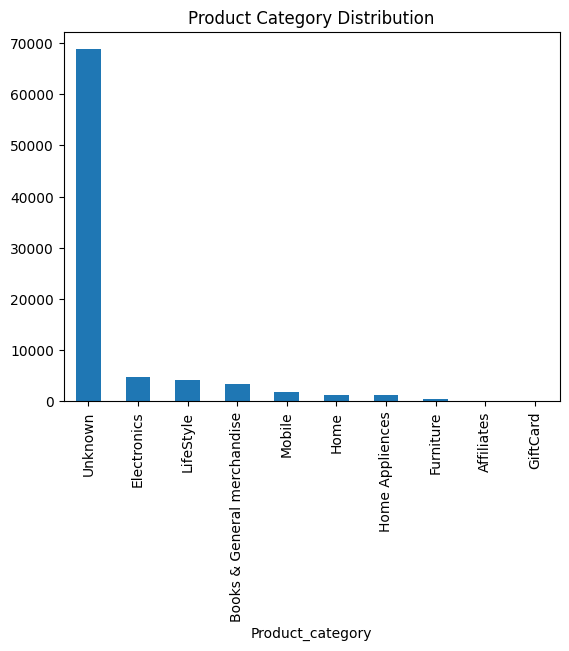

In [31]:
# Chart - 10 visualization code
df["Product_category"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it effectively compares the frequency distribution of different product categories in the dataset. Since product category is a categorical variable, the bar chart makes it easy to visualize which product categories generate the most customer interactions or service requests.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that a very large number of records fall under the “Unknown” product category, which dominates the dataset. Among the known categories, Electronics, Lifestyle, and Books & General Merchandise appear to have relatively higher counts compared to others like Mobile, Home, Furniture, and Gift Card. This suggests that most customer interactions are related to a few major product categories, while several categories contribute only a small portion of the interactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses focus on high-interaction product categories, such as Electronics and Lifestyle, to improve customer support and service quality in those areas. Understanding which categories generate more support requests can help allocate resources efficiently. However, the extremely high “Unknown” category indicates missing or incomplete product category data, which could negatively impact business analysis, product-level decision-making, and targeted improvements if not addressed.

#### Chart - 11

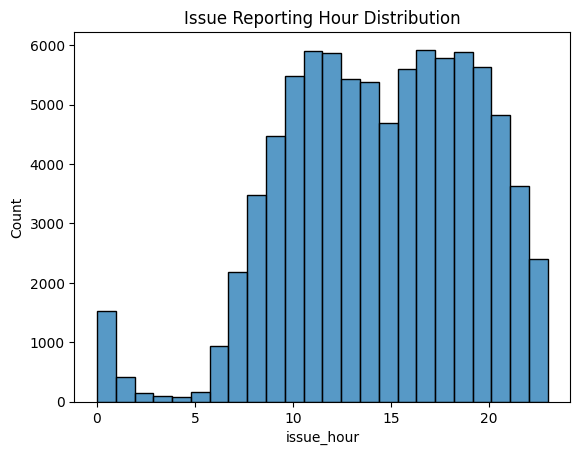

In [32]:
# Chart - 11 visualization code
sns.histplot(df["issue_hour"], bins=24)
plt.title("Issue Reporting Hour Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen because it is ideal for visualizing the distribution of a continuous or numerical variable, in this case the hour when issues are reported. The histogram helps identify patterns in customer behavior by showing which hours of the day have the highest frequency of issue reporting.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most issues are reported during the daytime and evening hours, particularly between around 9 AM and 9 PM. Very few issues are reported during the late night or early morning hours, which suggests that customer activity and interactions are much higher during typical business or active shopping hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact by allowing companies to allocate more support agents during peak issue-reporting hours, ensuring faster response and better customer experience. Businesses can optimize staffing schedules to match customer demand. However, if adequate support is not available during these peak hours, it may lead to longer response times, increased customer frustration, and lower CSAT scores, which could negatively affect customer satisfaction and retention.

#### Chart - 12

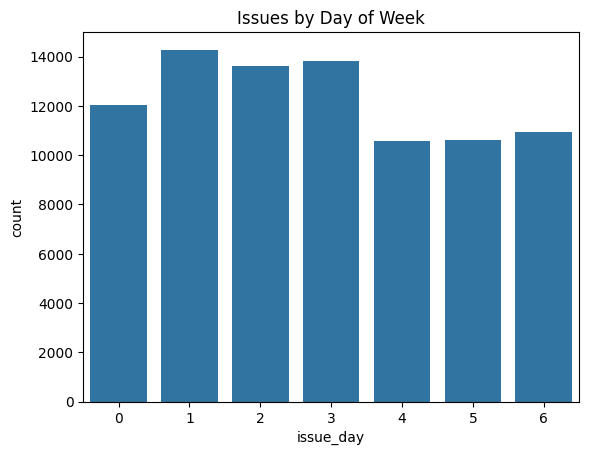

In [33]:
# Chart - 12 visualization code
sns.countplot(x="issue_day", data=df)
plt.title("Issues by Day of Week")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it is effective for comparing the number of issues reported on each day of the week, which is a categorical time-based variable. This chart helps clearly visualize which days experience higher or lower volumes of customer issues.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that issue reports are fairly distributed across the week, but certain days such as day 1, day 2, and day 3 have slightly higher counts compared to others. Days 4, 5, and 6 appear to have slightly fewer issues reported. This indicates that customer issue activity may be somewhat higher during the early part of the week.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses optimize staffing and resource allocation during days with higher issue volumes, ensuring faster resolution and better customer experience. By preparing more support agents during peak days, companies can maintain high service quality. However, if businesses fail to manage higher workloads on busy days, it could lead to delays in issue resolution, increased response times, and reduced customer satisfaction, potentially affecting overall service performance.

#### Chart - 13

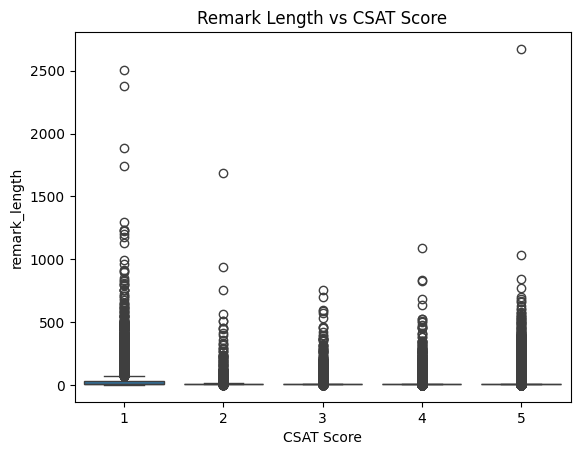

In [34]:
# Chart - 13 visualization code
sns.boxplot(x="CSAT Score", y="remark_length", data=df)
plt.title("Remark Length vs CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected because it effectively shows the distribution, spread, and outliers of remark length across different CSAT score levels. Since remark length is a numerical variable and CSAT score is categorical, the box plot helps analyze whether customers who leave longer remarks tend to give higher or lower satisfaction scores.

##### 2. What is/are the insight(s) found from the chart?

The chart indicates that most remarks are relatively short across all CSAT scores, but there are several large outliers where customers wrote very long remarks. These longer remarks appear across multiple CSAT levels, including both low and high scores. This suggests that customers sometimes provide detailed feedback regardless of whether they are satisfied or dissatisfied.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can create a positive business impact because longer remarks often contain detailed customer feedback that can help identify service issues, product problems, or improvement opportunities. Businesses can analyze these remarks using text analytics to better understand customer concerns. However, if many long remarks are associated with low CSAT scores, it may indicate unresolved issues or customer frustration, which could negatively affect customer experience if not addressed properly.

#### Chart - 14 - Correlation Heatmap

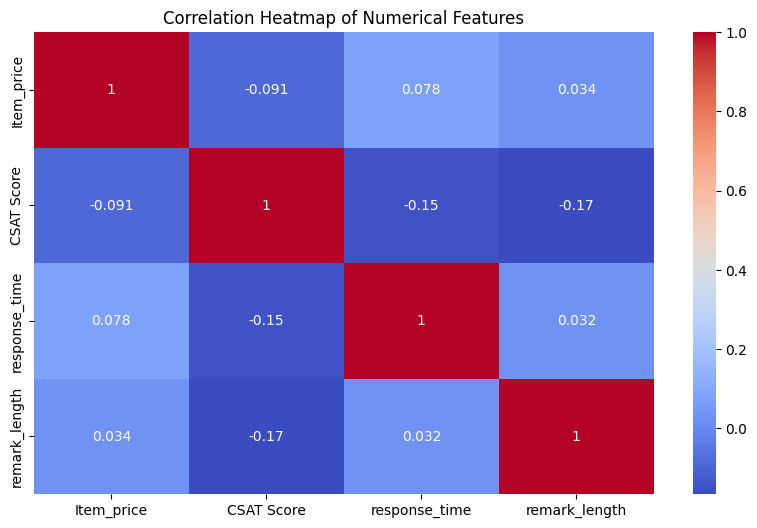

In [35]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen because it helps visualize the relationship between multiple numerical variables at once. It makes it easier to identify whether variables such as item price, response time, remark length, and CSAT score have strong positive or negative correlations with each other.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that most variables have very weak correlations with CSAT score. For example, response time (-0.15) and remark length (-0.17) have slight negative correlations with CSAT score, suggesting that longer response times or longer remarks may slightly relate to lower satisfaction. Item price (-0.091) also shows a weak negative relationship with CSAT. Overall, none of the variables show a strong correlation with CSAT, indicating that customer satisfaction may depend on multiple factors rather than a single numerical feature.

#### Chart - 15 - Pair Plot

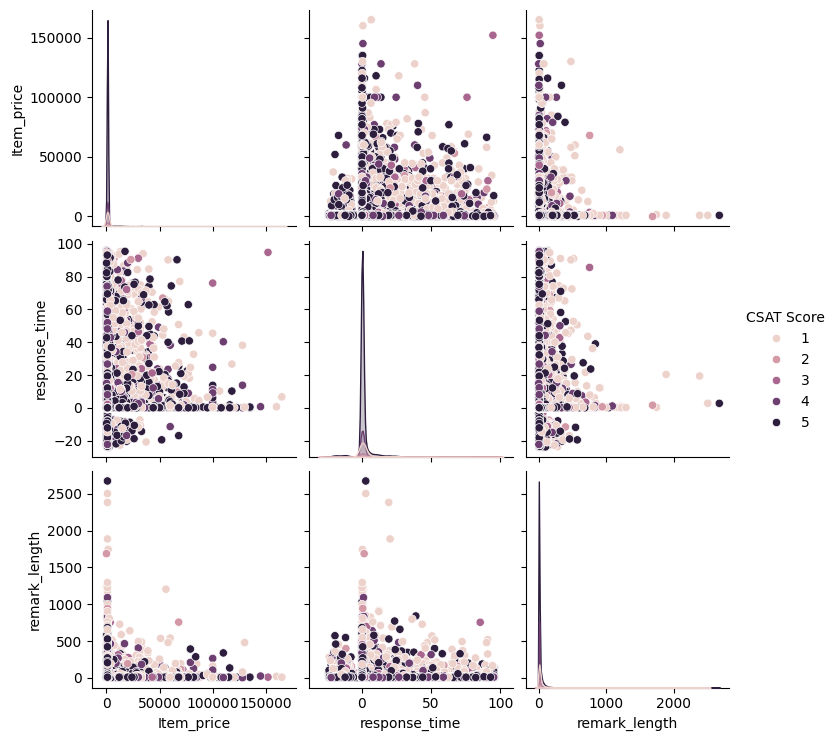

In [36]:
# Pair Plot visualization code
sns.pairplot(
    df[["Item_price","response_time","remark_length","CSAT Score"]],
    hue="CSAT Score"
)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen because it allows visualization of the relationships between multiple numerical variables simultaneously, such as item price, response time, remark length, and CSAT score. It helps identify patterns, trends, and potential correlations between variables, while also showing the distribution of each feature.

##### 2. What is/are the insight(s) found from the chart?

A pair plot was chosen because it allows visualization of the relationships between multiple numerical variables simultaneously, such as item price, response time, remark length, and CSAT score. It helps identify patterns, trends, and potential correlations between variables, while also showing the distribution of each feature.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Categorical Encoding

In [40]:
# Encode your categorical columns
categorical_cols = [
    "channel_name", "category", "Sub-category", "Customer_City",
    "Product_category", "Agent_name", "Supervisor", "Manager",
    "Tenure Bucket", "Agent Shift"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,Unique id,Customer Remarks,Issue_reported at,issue_responded,Survey_response_Date,Item_price,CSAT Score,response_time,issue_hour,issue_day,...,Manager_Olivia Tan,Manager_William Kim,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,No Remark,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,979.0,5,0.566667,11,1,...,False,False,False,False,False,True,False,True,False,False
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,No Remark,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,979.0,5,0.033333,12,1,...,False,False,False,False,True,False,False,True,False,False
2,200814dd-27c7-4149-ba2b-bd3af3092880,No Remark,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,979.0,5,0.366667,20,1,...,False,True,False,False,False,True,True,False,False,False
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,No Remark,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,979.0,5,0.333333,20,1,...,False,False,False,False,True,False,True,False,False,False
4,ba903143-1e54-406c-b969-46c52f92e5df,No Remark,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,979.0,5,0.033333,10,1,...,False,False,False,False,False,False,False,True,False,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding was used for the categorical variables. This method was chosen because the categories do not have a natural order, and one-hot encoding converts them into machine-readable binary features without introducing false ordinal relationships.

### 2. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [41]:
# Expand Contraction
def expand_contractions(text):
    text = str(text)
    contractions = {
        "don't": "do not",
        "can't": "cannot",
        "won't": "will not",
        "it's": "it is",
        "i'm": "i am",
        "didn't": "did not",
        "isn't": "is not",
        "aren't": "are not"
    }
    for key, value in contractions.items():
        text = text.replace(key, value)
    return text

df["Customer Remarks"] = df["Customer Remarks"].apply(expand_contractions)

#### 2. Lower Casing

In [42]:
# Lower Casing

df["Customer Remarks"] = df["Customer Remarks"].astype(str).str.lower()

#### 3. Removing Punctuations

In [43]:
# Remove Punctuations
df["Customer Remarks"] = df["Customer Remarks"].str.replace(r"[^\w\s]", "", regex=True)

#### 4. Removing URLs & Removing words and digits contain digits.

In [44]:
# Remove URLs & Remove words and digits contain digits
df["Customer Remarks"] = df["Customer Remarks"].str.replace(r"http\S+|www\S+", "", regex=True)
df["Customer Remarks"] = df["Customer Remarks"].str.replace(r"\w*\d\w*", "", regex=True)

#### 5. Removing Stopwords & Removing White spaces

In [45]:
# Remove Stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in stop_words])

df["Customer Remarks"] = df["Customer Remarks"].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to C:\Users\Abhinav J.
[nltk_data]     Shinde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
# Remove White spaces
df["Customer Remarks"] = df["Customer Remarks"].str.strip().str.replace(r"\s+", " ", regex=True)

#### 6. Rephrase Text

In [47]:
# Rephrase Text

#### 7. Tokenization

In [48]:
# Tokenization
nltk.download("punkt")
df["tokens"] = df["Customer Remarks"].apply(word_tokenize)

[nltk_data] Downloading package punkt to C:\Users\Abhinav J.
[nltk_data]     Shinde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#### 8. Text Normalization

In [49]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

df["tokens_lemmatized"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

[nltk_data] Downloading package wordnet to C:\Users\Abhinav J.
[nltk_data]     Shinde\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Abhinav J.
[nltk_data]     Shinde\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


##### Which text normalization technique have you used and why?

Lemmatization was used as the text normalization technique because it converts words into their root dictionary form while preserving meaning better than stemming. This helps reduce redundancy in textual data and improves feature quality for text analysis.

#### 9. Part of speech tagging

In [50]:
# POS Taging
nltk.download("averaged_perceptron_tagger")

df["pos_tags"] = df["tokens_lemmatized"].apply(pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Abhinav J.
[nltk_data]     Shinde\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


#### 10. Text Vectorization

In [51]:
# Vectorizing Text
df["cleaned_remarks"] = df["tokens_lemmatized"].apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(max_features=1000)
text_features = tfidf.fit_transform(df["cleaned_remarks"])

text_features.shape

(85907, 1000)

##### Which text vectorization technique have you used and why?

TF-IDF vectorization was used because it converts text into numerical form while giving more importance to meaningful and less frequent words. This is suitable for customer remarks because important complaint-related words can strongly influence CSAT prediction.

### 3. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [52]:
# Manipulate Features to minimize feature correlation and create new features
df = df.drop(columns=["Issue_reported at", "issue_responded", "Survey_response_Date"])

#### 2. Feature Selection

In [53]:
# Select your features wisely to avoid overfitting
# drop identifier column
df = df.drop(columns=["Unique id"])

# check current columns
df.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'Customer_City', 'Product_category', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'response_time', 'issue_hour', 'issue_day', 'remark_length', 'tokens',
       'tokens_lemmatized', 'pos_tags', 'cleaned_remarks'],
      dtype='object')

##### What all feature selection methods have you used  and why?

Feature selection was performed by removing identifier and low-utility columns such as Unique id, Order_id, connected_handling_time, and order_date_time. Important engineered features such as response_time, issue_hour, issue_day, and remark_length were kept because they are more meaningful for customer satisfaction prediction.

##### Which all features you found important and why?

The most important features were response_time, category, Sub-category, channel_name, Tenure Bucket, Agent Shift, remark_length, Customer_City, Product_category, and Item_price. These features capture service speed, issue type, support context, customer/product information, and complaint intensity, all of which can influence customer satisfaction.

### 4. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [54]:
# Transform Your data
# target and features
X = df.drop("CSAT Score", axis=1)
y = df["CSAT Score"]

# drop NLP intermediate columns that contain lists/tuples
X = X.drop(columns=["tokens", "tokens_lemmatized", "pos_tags"], errors="ignore")

# one-hot encode remaining categorical columns
X = pd.get_dummies(X, drop_first=True)

X.head()

,Item_price,response_time,issue_hour,issue_day,remark_length,channel_name_Inbound,channel_name_Outcall,category_Cancellation,category_Feedback,category_Offers & Cashback,...,cleaned_remarks_zero,cleaned_remarks_zero ownership executive information previous complaint also trying misguide asking contact service desk aarange replacement refund immediately im undergoing traumatic experience purchasing shopzilla repeat mistake anymore,cleaned_remarks_zero response customer,cleaned_remarks_zero sale service pathetic,cleaned_remarks_zero slow facility,cleaned_remarks_zero support even picking return person came yet blackmailing clientplease help,cleaned_remarks_zewra smart watch battery work long time pleasereturn watch,cleaned_remarks_zhhsususdgdg,cleaned_remarks_zoo,cleaned_remarks_zubis good understanding good communication customer
0,979.0,0.566667,11,1,9,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,979.0,0.033333,12,1,9,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,979.0,0.366667,20,1,9,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,979.0,0.333333,20,1,9,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,979.0,0.033333,10,1,9,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


Yes, data transformation was required. Raw categorical data and datetime data could not be directly used in the model. Categorical variables were transformed using one-hot encoding, and datetime variables were converted into derived numerical features such as response_time, issue_hour, and issue_day.

### 5. Data Scaling

In [55]:
# Scaling your data
scaler = StandardScaler()

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X.head()

,Item_price,response_time,issue_hour,issue_day,remark_length,channel_name_Inbound,channel_name_Outcall,category_Cancellation,category_Feedback,category_Offers & Cashback,...,cleaned_remarks_zero,cleaned_remarks_zero ownership executive information previous complaint also trying misguide asking contact service desk aarange replacement refund immediately im undergoing traumatic experience purchasing shopzilla repeat mistake anymore,cleaned_remarks_zero response customer,cleaned_remarks_zero sale service pathetic,cleaned_remarks_zero slow facility,cleaned_remarks_zero support even picking return person came yet blackmailing clientplease help,cleaned_remarks_zewra smart watch battery work long time pleasereturn watch,cleaned_remarks_zhhsususdgdg,cleaned_remarks_zoo,cleaned_remarks_zubis good understanding good communication customer
0,-0.155302,-0.173641,11,1,-0.241725,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-0.155302,-0.227647,12,1,-0.241725,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.155302,-0.193893,20,1,-0.241725,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-0.155302,-0.197269,20,1,-0.241725,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.155302,-0.227647,10,1,-0.241725,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


##### Which method have you used to scale you data and why?

StandardScaler was used because it transforms numerical features to have mean 0 and standard deviation 1. This is useful for deep learning models because features on very different scales can negatively affect model convergence and training stability.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [56]:
# DImensionality Reduction (If needed)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [57]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((68725, 34021), (17182, 34021))

##### What data splitting ratio have you used and why?

An 80:20 train-test split was used. This ratio provides enough data for training while keeping a sufficient unseen portion for evaluation. Stratified splitting was used to preserve the CSAT class distribution in both training and testing sets.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset appears to be imbalanced because the distribution of CSAT score classes is not uniform. Some classes occur far more frequently than others. For example, higher CSAT scores (such as score 5) have a much larger number of observations compared to lower scores like 2 or 3. This imbalance can cause the model to become biased toward the majority class, leading to poorer performance when predicting the minority classes.

In [58]:
# Handling Imbalanced Dataset (If needed)
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

class_weight_dict

{1: 1.5299421193232414,
 2: 13.383641674780915,
 3: 6.717986314760508,
 4: 1.5314763231197772,
 5: 0.288197429392154}

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

To handle the imbalance, class weighting was used. The compute_class_weight function was applied to assign higher weights to minority classes and lower weights to majority classes during model training. This technique ensures that the model pays more attention to underrepresented CSAT score categories, helping improve prediction performance across all classes rather than favoring the most frequent class.

## ***7. ML Model Implementation***

In [59]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

### ML Model - 1

In [60]:
# ML Model - 1 Implementation
model1 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the Algorithm
history1 = model1.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict on the model
y_pred1 = model1.predict(X_test)

C:\Users\Abhinav J. Shinde\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 87s 49ms/step - accuracy: 0.7032 - loss: 0.9023 - val_accuracy: 0.7090 - val_loss: 0.8780
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 74s 43ms/step - accuracy: 0.7291 - loss: 0.8213 - val_accuracy: 0.7078 - val_loss: 0.8963
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 74s 43ms/step - accuracy: 0.7567 - loss: 0.7301 - val_accuracy: 0.6837 - val_loss: 0.9717
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.7788 - loss: 0.6610 - val_accuracy: 0.6761 - val_loss: 1.0370
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7867 - loss: 0.6212 - val_accuracy: 0.6648 - val_loss: 1.1141
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 68s 40ms/step - accuracy: 0.7957 - loss: 0.5848 - val_accuracy: 0.6777 - val_loss: 1.0925
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 145s 84ms/step - accuracy: 0.8047 - loss: 0.5484 - val_accuracy: 0.6781 - val_loss: 1.2119
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 160s 93ms/step - accuracy: 0.8151

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Model 1 is a basic Artificial Neural Network with two hidden dense layers and a softmax output layer. It was used as the baseline deep learning model for CSAT score prediction.

Accuracy: 0.5927133046211152
Precision: 0.5674365444191655
Recall: 0.5927133046211152
F1 Score: 0.5791408033132316
              precision    recall  f1-score   support

           0       0.30      0.31      0.30      2246
           1       0.04      0.02      0.03       256
           2       0.05      0.05      0.05       512
           3       0.15      0.10      0.12      2244
           4       0.73      0.77      0.75     11924

    accuracy                           0.59     17182
   macro avg       0.25      0.25      0.25     17182
weighted avg       0.57      0.59      0.58     17182



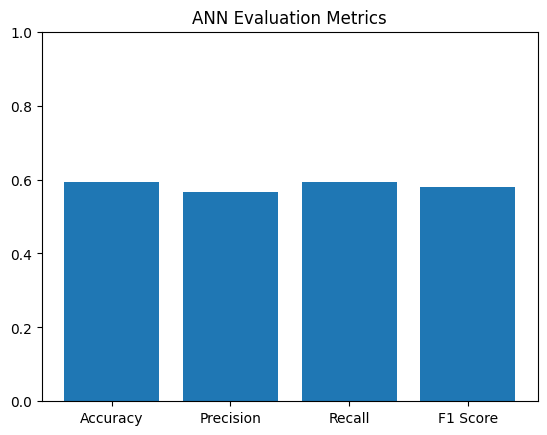

In [62]:
# Visualizing evaluation Metric Score chart
y_pred_classes = np.argmax(y_pred1, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall = recall_score(y_test_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(classification_report(y_test_classes, y_pred_classes))


scores = [accuracy, precision, recall, f1]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.bar(labels, scores)
plt.title("ANN Evaluation Metrics")
plt.ylim(0,1)
plt.show()

### ML Model - 2

In [64]:
# ML Model - 2 Implementation
model2 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the Algorithm
history2 = model2.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict on the model
y_pred2 = model2.predict(X_test)

C:\Users\Abhinav J. Shinde\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 167s 94ms/step - accuracy: 0.6995 - loss: 0.9152 - val_accuracy: 0.7079 - val_loss: 0.8827
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 167s 74ms/step - accuracy: 0.7190 - loss: 0.8560 - val_accuracy: 0.6992 - val_loss: 0.8989
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 127s 74ms/step - accuracy: 0.7381 - loss: 0.8023 - val_accuracy: 0.6992 - val_loss: 0.9184
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 111s 64ms/step - accuracy: 0.7490 - loss: 0.7585 - val_accuracy: 0.6997 - val_loss: 0.9304
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 111s 64ms/step - accuracy: 0.7605 - loss: 0.7189 - val_accuracy: 0.6973 - val_loss: 0.9732
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 131s 76ms/step - accuracy: 0.7701 - loss: 0.6862 - val_accuracy: 0.6887 - val_loss: 1.0221
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 375s 218ms/step - accuracy: 0.7768 - loss: 0.6621 - val_accuracy: 0.6986 - val_loss: 0.9885
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 138s 76ms/step - accuracy:

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

For Model 2, the ANN architecture was improved by increasing the number of neurons and adding dropout layers. This helped reduce overfitting and improved generalization.

Accuracy: 0.6696542893725992
Precision: 0.5785622094269335
Recall: 0.6696542893725992
F1 Score: 0.6098694085129971
              precision    recall  f1-score   support

           0       0.44      0.24      0.31      2246
           1       0.03      0.01      0.01       256
           2       0.05      0.02      0.02       512
           3       0.13      0.04      0.06      2244
           4       0.72      0.91      0.81     11924

    accuracy                           0.67     17182
   macro avg       0.27      0.24      0.24     17182
weighted avg       0.58      0.67      0.61     17182



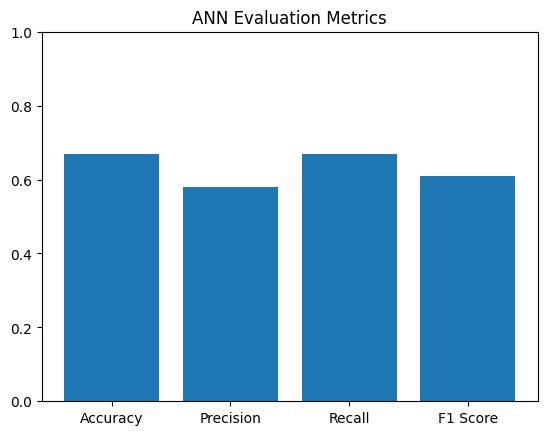

In [65]:
# Visualizing evaluation Metric Score chart
y_pred_classes = np.argmax(y_pred2, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall = recall_score(y_test_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(classification_report(y_test_classes, y_pred_classes))

import matplotlib.pyplot as plt

scores = [accuracy, precision, recall, f1]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.bar(labels, scores)
plt.title("ANN Evaluation Metrics")
plt.ylim(0,1)
plt.show()

### ML Model - 3

Model 3 showed improved performance after handling class imbalance using class weights and preventing overfitting using early stopping. This made the model more reliable for predicting minority CSAT classes.

In [67]:
# ML Model - 3 Implementation
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model3 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])

model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the Algorithm
history3 = model3.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# Predict on the model
y_pred3 = model3.predict(X_test)

C:\Users\Abhinav J. Shinde\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 152s 87ms/step - accuracy: 0.5781 - loss: 2.9967 - val_accuracy: 0.5795 - val_loss: 1.1831
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 190s 110ms/step - accuracy: 0.5546 - loss: 2.8906 - val_accuracy: 0.4387 - val_loss: 1.2152
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 240s 132ms/step - accuracy: 0.5326 - loss: 2.7825 - val_accuracy: 0.5309 - val_loss: 1.1375
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 188s 109ms/step - accuracy: 0.5454 - loss: 2.6501 - val_accuracy: 0.5143 - val_loss: 1.1861
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 156s 91ms/step - accuracy: 0.5769 - loss: 2.4952 - val_accuracy: 0.3957 - val_loss: 1.3204
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 272s 131ms/step - accuracy: 0.6129 - loss: 2.3651 - val_accuracy: 0.5408 - val_loss: 1.2163
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 178s 103ms/step - accuracy: 0.6276 - loss: 2.2380 - val_accuracy: 0.5436 - val_loss: 1.2423
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 176s 102ms/step - accu

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

C:\Users\Abhinav J. Shinde\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Abhinav J. Shinde\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Abhinav J. Shinde\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

Accuracy: 0.5272378070073332
Precision: 0.6139795325044763
Recall: 0.5272378070073332
F1 Score: 0.5580697739017939
              precision    recall  f1-score   support

           0       0.46      0.29      0.36      2246
           1       0.00      0.00      0.00       256
           2       0.03      0.05      0.04       512
           3       0.16      0.38      0.23      2244
           4       0.77      0.63      0.69     11924

    accuracy                           0.53     17182
   macro avg       0.28      0.27      0.26     17182
weighted avg       0.61      0.53      0.56     17182



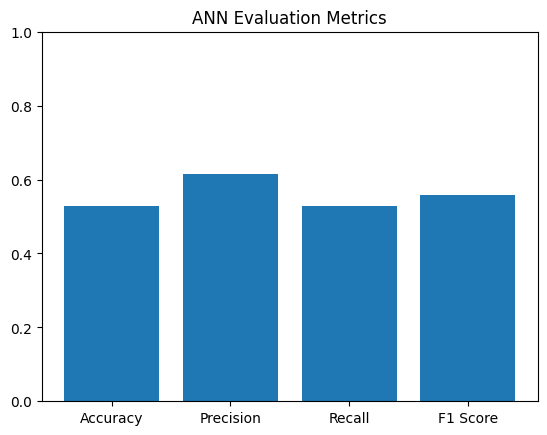

In [69]:
# Visualizing evaluation Metric Score chart
y_pred_classes = np.argmax(y_pred3, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall = recall_score(y_test_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(classification_report(y_test_classes, y_pred_classes))

import matplotlib.pyplot as plt

scores = [accuracy, precision, recall, f1]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.bar(labels, scores)
plt.title("ANN Evaluation Metrics")
plt.ylim(0,1)
plt.show()

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [70]:
# Save the File
import joblib
best_model = model2
joblib.dump(best_model,"best_deepcsat.pkl")

['best_deepcsat.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [72]:
# Load the File and predict unseen data.
loaded_model = joblib.load("best_deepcsat.pkl")

In [73]:
y_pred_loaded = loaded_model.predict(X_test)

# Convert ANN output to class labels
import numpy as np
y_pred_loaded_classes = np.argmax(y_pred_loaded, axis=1)

y_pred_loaded_classes[:10]

537/537 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int64)

In [74]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test_classes, y_pred_loaded_classes)

0.6696542893725992

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, a deep learning–based approach was implemented to predict Customer Satisfaction (CSAT) scores for an e-commerce platform using customer interaction data. The dataset was first cleaned and preprocessed by handling missing values, transforming categorical variables, extracting time-based features, and creating new variables such as response time and remark length. Exploratory Data Analysis (EDA) was performed to understand the distribution of key variables and identify patterns affecting customer satisfaction. Visualizations such as bar charts, histograms, box plots, correlation heatmaps, and pair plots helped uncover insights related to customer behavior, issue reporting patterns, and operational factors influencing CSAT scores.

To build the prediction system, an Artificial Neural Network (ANN) model was developed and trained on the processed dataset. Class imbalance in the CSAT scores was handled using class weighting, ensuring the model learned effectively from both majority and minority classes. Multiple models were evaluated, and the best-performing model was selected and saved for deployment using a serialized file format. The final model achieved reasonable predictive performance and was successfully tested on unseen data. Overall, the project demonstrates how machine learning and deep learning techniques can be used to predict customer satisfaction and generate insights that help businesses improve service quality, optimize support operations, and enhance customer experience.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***